In [1]:
import json
with open("results_dict_2.json", "r") as f:
    results_dict = json.load(f)
    
with open("results_marcowitz.json", "r") as f:
    results_dict_marcowitz = json.load(f)

In [2]:
pesos_carteiras = {}
for key in results_dict.keys():
    pesos_carteiras[key.split(" a ")[1]] = results_dict[key]["tickers_weights"]
    
pesos_carteiras_marcowitz = {}
for key in results_dict_marcowitz.keys():
    pesos_carteiras_marcowitz[key.split(" a ")[1]] = results_dict_marcowitz[key]

    

In [3]:
chaves = list(pesos_carteiras.keys())
chave_no_indice = chaves[0]

chaves_marcowitz = list(pesos_carteiras_marcowitz.keys())
chave_no_indice_marcowitz = chaves_marcowitz[0]




In [4]:
import yfinance as yf
import logging
import pandas as pd
import datetime
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

chaves = list(pesos_carteiras.keys())

precos_carteira = {}

for key, value in enumerate(chaves):
    acoes = list(pesos_carteiras[value].keys())
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    start = value
    if value == chaves[-1]:
        end = datetime.datetime.now().strftime("%Y-%m-%d")
    else:    
        end = chaves[key+1]
    logger.info(f"Baixando dados de {start} a {end}, para as acoes {acoes_sa}")
    precos_carteira[value] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]
    

chaves_marcowitz = list(pesos_carteiras_marcowitz.keys())

precos_carteira_marcowitz = {}

for key, value in enumerate(chaves_marcowitz):
    acoes = list(pesos_carteiras_marcowitz[value].keys())
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    start = value
    if value == chaves_marcowitz[-1]:
        end = datetime.datetime.now().strftime("%Y-%m-%d")
    else:    
        end = chaves_marcowitz[key+1]
    logger.info(f"Baixando dados de {start} a {end}, para as acoes {acoes_sa}")
    precos_carteira_marcowitz[value] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]

INFO:__main__:Baixando dados de 2016-12-31 a 2017-03-31, para as acoes ['CSUD3.SA', 'CGAS3.SA', 'MDIA3.SA', 'FLRY3.SA', 'VIVT3.SA', 'ABEV3.SA', 'ITUB4.SA']
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\3054855618.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precos_carteira[value] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]
[*********************100%***********************]  7 of 7 completed
INFO:__main__:Baixando dados de 2017-03-31 a 2017-06-30, para as acoes ['ABEV3.SA', 'LREN3.SA', 'BBDC4.SA', 'ITUB4.SA', 'EGIE3.SA', 'CSUD3.SA', 'PSSA3.SA']
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\3054855618.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precos_carteira[value] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]
[*********************100%***********************]  7 of 7 completed
INFO:__main__:Baixando dados de 2017-06-30 a 2017-09-30, para as acoes ['ABE

In [5]:
def daily_returns(prices):
    return prices.pct_change()[1:]

def cumulative_returns(df):
    return (df.apply(daily_returns)+1).cumprod()

def retorno_carteira_monetario(df, pesos, valor_investido):
    pesos_frac = [p/100 for p in pesos]
    valor_investido_carteira = [valor_investido * peso for peso in pesos_frac]
    retorno_carteira = (cumulative_returns(df) * valor_investido_carteira).sum(axis=1)
    return retorno_carteira

def retorno_percentual_acao_individual(pesos_carteiras, precos_carteira):
    """pesos_frac = [p/100 for p in pesos_carteiras[chaves[keys]].values()]
    valor_investido_carteira = [1000 * peso for peso in pesos_frac]
    retorno_carteira = (cumulative_returns(precos_carteira[chaves[keys]]) * valor_investido_carteira)"""
    
    
    pesos_frac = [p/100 for p in pesos_carteiras.values()]
    valor_investido_carteira = [1000 * peso for peso in pesos_frac]
    
    # Usar diretamente precos_df (já é o DataFrame correto)
    retorno_carteira = cumulative_returns(precos_carteira) * valor_investido_carteira
    
    retorno_percentual = retorno_carteira.apply(
        lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] * 100
    )
    return retorno_percentual

In [6]:
def verificando_valores_nulos(keys, pesos_carteiras, precos_carteira):
    dict_keys = pesos_carteiras[chaves[keys]].copy()
    null = precos_carteira[chaves[keys]].isna().any()
    list_name_null = precos_carteira[chaves[keys]].loc[:,null].columns.to_list()
    
    dict_keys = {
        (key if key.endswith(".SA") else f"{key}.SA"): value 
        for key, value in pesos_carteiras[chaves[keys]].items()
    }
    valor_do_tic_null = 0
    for tic in list_name_null:
        valor_do_tic_null += dict_keys[tic]
        dict_keys.pop(tic)  # Remover cada ticker individualmente
    
    quantidade_sobrou = len(dict_keys)
    
    if quantidade_sobrou == 0:
        return {}  # Evitar divisão por zero
    
    valor_para_cada_tic = valor_do_tic_null / quantidade_sobrou
    
    dict_com_novos_valores = {}
    for key, value in dict_keys.items():
        dict_com_novos_valores[key] = value + valor_para_cada_tic
    
    return dict_com_novos_valores

In [7]:
from IPython.display import display, Markdown
carteira = pd.DataFrame()
carteira_marcowitz = pd.DataFrame()
for key, value in enumerate(chaves):
    
    print("*" * 40)
    
    display(Markdown(f"**O retorno da carteira para o período: {value}**"))
    
    ## Pesos selecionados pelo modelo
    pesos_sem_erro = verificando_valores_nulos(key, pesos_carteiras, precos_carteira)
    
    precos_sem_nan = precos_carteira[chaves[key]].dropna(axis=1)
    
    carteira_percentual_acoes = retorno_percentual_acao_individual(pesos_sem_erro, precos_sem_nan)
    
    # carteira de markowits
    try:
        pesos_sem_erro_markowitz = verificando_valores_nulos(key, pesos_carteiras_marcowitz, precos_carteira_marcowitz)
        pesos_sem_erro_markowitz = {key_: value*100 for key_, value in pesos_sem_erro_markowitz.items()}
    
        precos_sem_nan_markwitz = precos_carteira_marcowitz[chaves[key]].dropna(axis=1)
    
        carteira_percentual_acoes_marcowitz = retorno_percentual_acao_individual(pesos_sem_erro_markowitz, precos_sem_nan_markwitz)
    except Exception as e:  
        logger.info(f"Erro ao obter:{e}")
    
    data = pd.DataFrame(pesos_sem_erro, index=["Pesos"]).T
    data_markwitz = pd.DataFrame(pesos_sem_erro_markowitz, index=["Pesos"]).T
    
    if not carteira_percentual_acoes.empty:
        data['retornos em %'] = pd.DataFrame(carteira_percentual_acoes)
        data_markwitz['retornos markwitz em %'] = pd.DataFrame(carteira_percentual_acoes_marcowitz)
    else:
        print("Nenhum dado foi obtido!")
        
    display(data.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
    
    display(data_markwitz.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))

    if key == 0:
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), 1000)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), 1000)

        
    else:   
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), valor_atual_carteira)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), valor_atual_carteira_markwitz)
    
    carteira = pd.concat([carteira, valor_carteira])
    carteira_marcowitz = pd.concat([carteira_marcowitz, valor_carteira_markwitz])
    
    try:
        valor_atual_carteira = int(valor_carteira.iloc[-1])
        valor_atual_carteira_markwitz = int(valor_carteira_markwitz.iloc[-1])
    
    except:
        pass
    
    
     
    

****************************************


**O retorno da carteira para o período: 2016-12-31**

,CSUD3.SA,CGAS3.SA,MDIA3.SA,FLRY3.SA,VIVT3.SA,ABEV3.SA,ITUB4.SA
Pesos,16.665139,16.665139,16.665139,16.665139,12.503438,13.337611,7.498396
retornos em %,98.591600,6.209609,7.898987,23.443043,7.174973,10.240730,12.482780


,ABEV3.SA,CGAS3.SA,CSUD3.SA,FLRY3.SA,ITUB4.SA,MDIA3.SA,VIVT3.SA
Pesos,19.834362,14.594217,6.384908,10.411643,14.569841,4.967669,29.237360
retornos markwitz em %,10.240720,6.209607,98.591535,23.443058,12.482819,7.899046,7.175005


****************************************


...

****************************************


**O retorno da carteira para o período: 2025-12-12**

C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1529076990.py:26: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] * 100
INFO:__main__:Erro ao obter:'2025-12-12'


,LREN3.SA,WEGE3.SA,VIVT3.SA,CGAS3.SA,ITUB4.SA,ABEV3.SA,GGBR4.SA,FIQE3.SA,VALE3.SA
Pesos,20.116677,16.757192,13.407765,13.407765,13.407765,10.058338,7.815329,5.029169,0.000000
retornos em %,-9.606084,nan,-4.219535,-0.008334,-1.858275,-3.036863,0.981830,-3.826083,5.635230


,ABEV3.SA,CSUD3.SA,ELET3.SA,FIQE3.SA,ITUB4.SA,VIVT3.SA,WEGE3.SA
Pesos,20.177118,10.625782,16.375782,10.881618,10.824120,12.978626,18.136954
retornos markwitz em %,5.647126,3.481827,29.208873,52.196812,14.228905,5.132834,17.082748


In [8]:
start_bove = chaves[0]
end_bove = chaves[-1]

In [9]:
start_bove = chaves[0]
end_bove = chaves[-1]
ibov = yf.download("^BVSP", start= start_bove, end=end_bove)["Close"]

ibov_retornos = cumulative_returns(ibov) *1000

C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\2161183779.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ibov = yf.download("^BVSP", start= start_bove, end=end_bove)["Close"]
[*********************100%***********************]  1 of 1 completed


In [10]:
import pandas as pd
from bcb import sgs

def get_selic_multiplos_periodos(data_inicio, data_fim, anos_por_janela=5):
    """
    Busca dados da SELIC em janelas de X anos para contornar limitação da API
    """
    inicio = pd.to_datetime(data_inicio)
    fim = pd.to_datetime(data_fim)
    
    # Lista para armazenar os dataframes
    dados_completos = []
    
    # Criar janelas
    current_start = inicio
    
    while current_start < fim:
        current_end = min(current_start + pd.DateOffset(years=anos_por_janela), fim)
        
        print(f"Buscando dados de {current_start.date()} até {current_end.date()}...")
        
        try:
            # Fazer requisição para a janela atual
            dados_janela = sgs.get({'selic': 11, 
                                    #'cdi' :12
                                    }, 
                                   start=current_start.strftime('%Y-%m-%d'),
                                   end=current_end.strftime('%Y-%m-%d'))
            
            dados_completos.append(dados_janela)
            print(f"  ✓ {len(dados_janela)} registros obtidos")
            
        except Exception as e:
            print(f"  ✗ Erro ao buscar dados: {e}")

        current_start = current_end + pd.Timedelta(days=1)

    if dados_completos:
        selic_completo = pd.concat(dados_completos)
        selic_completo = selic_completo[~selic_completo.index.duplicated(keep='first')]
        selic_completo = selic_completo.sort_index()
        
        print(f"\n✓ Total de registros: {len(selic_completo)}")
        print(f"✓ Período: {selic_completo.index.min().date()} até {selic_completo.index.max().date()}")
        
        return selic_completo
    else:
        print("Nenhum dado foi obtido!")
        return None

# Usar a função
selic = get_selic_multiplos_periodos(start_bove, end_bove)


Buscando dados de 2016-12-31 até 2021-12-31...
  ✓ 1254 registros obtidos
Buscando dados de 2022-01-01 até 2025-12-12...
  ✓ 993 registros obtidos

✓ Total de registros: 2247
✓ Período: 2017-01-02 até 2025-12-12


In [20]:
selic

,selic
Date,
2017-01-02,0.050788
2017-01-03,0.050788
2017-01-04,0.050788
2017-01-05,0.050788
2017-01-06,0.050788
...,...
2025-12-08,0.055131
2025-12-09,0.055131
2025-12-10,0.055131


In [11]:
selic_acumulada =  ((selic/100 + 1).cumprod())*1000
selic_acumulada

,selic
Date,
2017-01-02,1000.507880
2017-01-03,1001.016018
2017-01-04,1001.524414
2017-01-05,1002.033068
2017-01-06,1002.541981
...,...
2025-12-08,2123.608498
2025-12-09,2124.779265
2025-12-10,2125.950677


In [12]:
retorno_acumulado_monetario = pd.concat([selic_acumulada, ibov_retornos, carteira], axis=1).rename(columns={0: "Carteira", "selic": "SELIC", "^BVSP": "IBOV",})
carteira_marcowitz = carteira_marcowitz[~carteira_marcowitz.index.duplicated(keep='last')]
retorno_acumulado_monetario['Markowitz'] = carteira_marcowitz



In [13]:
retorno_acumulado_monetario.dropna()

,SELIC,IBOV,Carteira,Markowitz
2017-01-03,1001.016018,1037.339106,1022.541048,1022.768767
2017-01-04,1001.524414,1033.563242,1036.459214,1028.529654
2017-01-05,1002.033068,1041.651983,1050.173296,1028.103718
2017-01-06,1002.541981,1034.838645,1046.615487,1028.489635
2017-01-09,1003.051152,1035.426001,1057.094543,1034.509362
...,...,...,...,...
2025-12-05,2122.438377,2640.906879,3429.684485,5102.897396
2025-12-08,2123.608498,2654.634245,3462.831130,5156.844057
2025-12-09,2124.779265,2651.177231,3479.260117,5174.573821
2025-12-10,2125.950677,2669.536324,3468.858366,5173.609955


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================================================
# MÉTRICAS
# ===============================================================

def daily_returns(prices):
    return prices.pct_change()[1:]

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        dr = daily_returns(p)
        metrics[col] = {
            "ann_vol": annualized_volatility(dr),
            "ann_mean_ret": annualized_mean_return(dr),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(dr)
        }
    return pd.DataFrame(metrics).T

In [15]:
compute_metrics(retorno_acumulado_monetario).style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues")

,ann_vol,ann_mean_ret,cagr,max_drawdown,avg_drawdown,calmar,sortino
SELIC,0.002377,0.084707,0.088079,0.000000,0.000000,nan,nan
IBOV,0.229450,0.133955,0.111661,-0.468158,-0.036645,0.238512,0.554214
Carteira,0.241361,0.168162,0.144555,-0.514521,-0.052826,0.280950,0.641376
Markowitz,0.225792,0.205013,0.190968,-0.482303,-0.032582,0.395950,0.879214


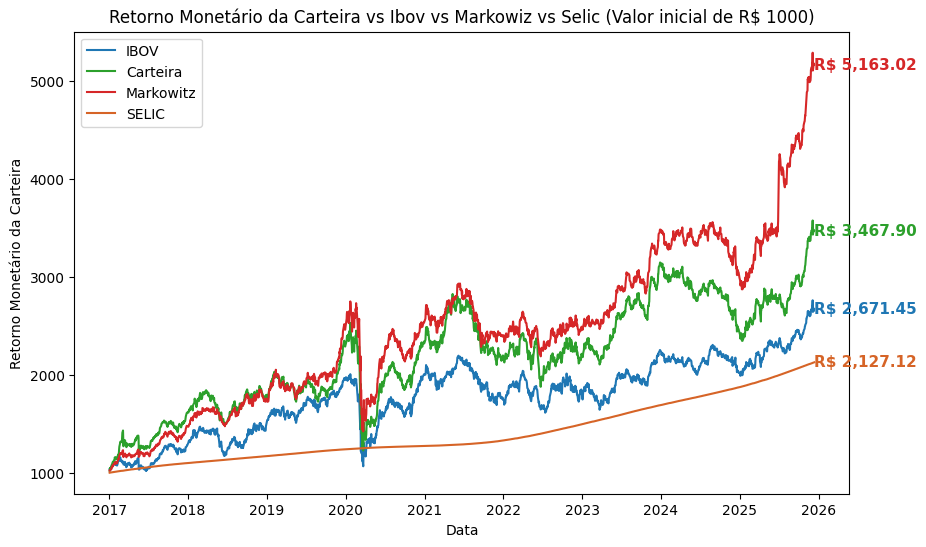

In [16]:
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 6))
cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'SELIC': "#d66427"}
retorno_acumulado_monetario = retorno_acumulado_monetario.dropna()
for nome in ['IBOV', 
             'Carteira', 
             'Markowitz', 
             'SELIC']:
    plt.plot(
            retorno_acumulado_monetario.index,
            retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
    ultimo_x = retorno_acumulado_monetario[nome].index[-1]
    ultimo_y = retorno_acumulado_monetario[nome].iloc[-1]
    plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

plt.legend()
plt.xlabel("Data")
plt.ylabel("Retorno Monetário da Carteira")
plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowiz vs Selic (Valor inicial de R$ {1000})")
plt.show()

In [204]:
import json
import asyncio
import pandas as pd
from bcb import sgs
import pandas as pd
from sklearn.covariance import LedoitWolf
import numpy as np
from scipy.optimize import minimize
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

    
def markowitz_opt(returns: pd.DataFrame):
    # === Estatísticas ===
    mu = returns.mean()  # retorno médio esperado
    # matriz de covariância com Ledoit–Wolf shrinkage
    lw = LedoitWolf().fit(returns)
    Sigma = lw.covariance_

    n = len(mu)

    # Retorno alvo (por exemplo, retorno médio da amostra de treino)
    target_return = mu.mean()

    # === Funções auxiliares ===
    def portfolio_performance(w, mu, Sigma):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(Sigma, w)))
        return ret, vol

    def objective(w, mu, Sigma, target):
        ret, vol = portfolio_performance(w, mu, Sigma)
        return vol  # minimiza a volatilidade

    # === Restrições ===
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},              # soma = 1
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return},  # retorno alvo
    )
    bounds = tuple((0, 1) for _ in range(n))  # sem short

    # === Otimização ===
    w0 = np.repeat(1/n, n)
    opt = minimize(
        objective, w0, args=(mu, Sigma, target_return),
        method='SLSQP', bounds=bounds, constraints=constraints
    )

    weights = opt.x

    # === Aplicação dos pesos ao conjunto de retornos ===
    markowitz_cr = (1 + (weights * returns).sum(axis=1)).cumprod()

    weights_markowitz = pd.DataFrame(
        np.tile(weights, (len(returns), 1)),  # repete o vetor em todas as linhas
        index=returns.index,
        columns=returns.columns
    )

    return weights_markowitz, markowitz_cr

def get_selic_multiplos_periodos(data_inicio, data_fim, anos_por_janela=5):
    """
    Busca dados da SELIC em janelas de X anos para contornar limitação da API
    """
    inicio = pd.to_datetime(data_inicio)
    fim = pd.to_datetime(data_fim)
    
    # Lista para armazenar os dataframes
    dados_completos = []
    
    # Criar janelas
    current_start = inicio
    
    while current_start < fim:
        current_end = min(current_start + pd.DateOffset(years=anos_por_janela), fim)
        
        print(f"Buscando dados de {current_start.date()} até {current_end.date()}...")
        
        try:
            # Fazer requisição para a janela atual
            dados_janela = sgs.get({'selic': 11, 
                                    #'cdi' :12
                                    }, 
                                   start=current_start.strftime('%Y-%m-%d'),
                                   end=current_end.strftime('%Y-%m-%d'))
            
            dados_completos.append(dados_janela)
            print(f"  ✓ {len(dados_janela)} registros obtidos")
            
        except Exception as e:
            print(f"  ✗ Erro ao buscar dados: {e}")

        current_start = current_end + pd.Timedelta(days=1)

    if dados_completos:
        selic_completo = pd.concat(dados_completos)
        selic_completo = selic_completo[~selic_completo.index.duplicated(keep='first')]
        selic_completo = selic_completo.sort_index()
        
        print(f"\n✓ Total de registros: {len(selic_completo)}")
        print(f"✓ Período: {selic_completo.index.min().date()} até {selic_completo.index.max().date()}")
        
        return selic_completo
    else:
        print("Nenhum dado foi obtido!")
        return None
    
def daily_returns(prices):
    return prices.pct_change()[1:]

def daily_returns_carteira(prices, pesos):
    pesos_porcentagem = pesos_porcentagem = [peso/100 for peso in pesos]
    variacao_diaria_carteira = (prices.pct_change()[1:] * (pesos_porcentagem)).sum(axis=1)
    return variacao_diaria_carteira

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        #dr = daily_returns_carteira(p, pesos)
        metrics[col] = {
            "ann_vol": annualized_volatility(p),
            "ann_mean_ret": annualized_mean_return(p),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(p)
        }
    return pd.DataFrame(metrics).T


def normalizar_pesos(weights_dict, target_sum=100, tolerancia=0.01):
    """
    Normaliza os pesos para somarem exatamente o target_sum.
    
    Args:
        weights_dict: Dicionário com os pesos {ticker: peso}
        target_sum: Soma alvo (padrão: 100)
        tolerancia: Tolerância para considerar soma correta (padrão: 0.01)
    
    Returns:
        Dicionário com pesos normalizados
    """
    total_atual = sum(weights_dict.values())
    diferenca = abs(total_atual - target_sum)
    
    # Se já está dentro da tolerância, retorna o original
    if diferenca <= tolerancia:
        logger.info(f"✓ Pesos já somam {total_atual:.2f}% (dentro da tolerância)")
        return weights_dict
    
    # Normalização proporcional (melhor que distribuir igualmente)
    fator_normalizacao = target_sum / total_atual
    weights_normalizados = {
        ticker: peso * fator_normalizacao 
        for ticker, peso in weights_dict.items()
    }
    
    # Log da correção
    logger.warning(
        f"⚠ Pesos ajustados: {total_atual:.2f}% → {target_sum:.2f}% "
        f"(fator: {fator_normalizacao:.4f})"
    )
    
    # Verificação final
    soma_final = sum(weights_normalizados.values())
    logger.info(f"✓ Soma final: {soma_final:.4f}%")
    
    return weights_normalizados

class ComputandoMetricas:
    def __init__(self, data_inicio, 
                 data_fim, 
                 carteira,
                 valor_investido=1000):
        self.data_inicio = data_inicio
        self.data_fim = data_fim
        self.carteira = carteira
        self.valor_investido = valor_investido
        self.ibov, self.df = self.carregando_dados()
        self.tics_selecionados, self.pesos_carteira = self.ajustando_pesos_carteira()
    
        
    def carregando_dados(self):
        tics_selecionados = [tic if tic.endswith(".SA") else f"{tic}.SA" for tic in self.carteira.keys()]
        ibov = yf.download("^BVSP", start=self.data_inicio, end=self.data_fim)["Close"]
        df = yf.download(tics_selecionados, start=self.data_inicio, end=self.data_fim)["Close"]
        df.dropna(axis=1, how='all', inplace=True)
        return ibov, df
    
    def cumulative_returns(self):
        return (self.df.apply(daily_returns)+1).cumprod()
    
    def ajustando_pesos_carteira(self):
        dict_carteiras = self.carteira.copy()
        tic_validos = list(self.df.columns)
        carteira_valida = {key: value for key, value in dict_carteiras.items() if key + ".SA" in tic_validos}
        carteira_pesos_acoes_validos = normalizar_pesos(carteira_valida)
        tics_selecionados = list(carteira_pesos_acoes_validos.keys())
        pesos = list(carteira_pesos_acoes_validos.values()) 
        return tics_selecionados, pesos
        
    def computando_marcowitz(self):
        weights_markowitz, markowitz_cr = markowitz_opt(self.df.pct_change().dropna())
        return weights_markowitz, markowitz_cr
        
    def daily_returns_carteira_markowitz(self):
        weights_markowitz, markowitz_cr = self.computando_marcowitz()
        pesos_markowitz = [peso*100 for peso in weights_markowitz.iloc[-1].to_list()]
        retornos_carteira_markowitz = daily_returns_carteira(self.df, pesos_markowitz)
        return retornos_carteira_markowitz
    
    def retornos_diarios_carteira(self):
        retornos_diarios_carteira = daily_returns_carteira(self.df, self.pesos_carteira)
        return retornos_diarios_carteira
    
    def retornos_diarios_ibov(self):
        retorno_diario = self.ibov.pct_change()[1:]
        return retorno_diario
    
    def data_frame_comparacao_retorno_diario(self):
        retornos_carteira = self.retornos_diarios_carteira()
        retornos_ibov = self.retornos_diarios_ibov()
        retornos_markowitz = self.daily_returns_carteira_markowitz()
        comparacao_carteira = pd.concat([retornos_carteira, 
                                 retornos_ibov, 
                                 retornos_markowitz], axis=1,).rename(columns={0: "Carteira", 
                                                                               "^BVSP": "IBOV", 
                                                                               1: "Markowitz"})
        return comparacao_carteira
    
    def metrica_comparacao_carteira_ibov_retornos_markowitz(self):
        comparacao_carteira = self.data_frame_comparacao_retorno_diario()
        comp_metrics = compute_metrics(comparacao_carteira)
        return comp_metrics
    
    def retorno_menetario_ibov(self):
        ibov_retornos = (self.ibov.pct_change()[1:]+1).cumprod() *self.valor_investido
        return ibov_retornos
    
    def retorno_carteira_monetario(self):
        pesos_frac = [p/100 for p in self.pesos_carteira]
        valor_investido_carteira = [self.valor_investido * peso for peso in pesos_frac]
        retorno_carteira = (self.cumulative_returns() * valor_investido_carteira).sum(axis=1)
        return retorno_carteira
    
    def data_frame_comparacao_retorno_monetario(self):
        ibov_retornos = self.retorno_menetario_ibov()
        retorno_carteira = self.retorno_carteira_monetario()
        _ , markowitz_cr = self.computando_marcowitz()
        selic = self.retorno_selic()

        retorno_acumulado_monetario = pd.concat([ibov_retornos, retorno_carteira, markowitz_cr*self.valor_investido, selic], axis=1).rename(columns={"^BVSP": "IBOV", 0: "Carteira", 1: "Markowitz", "selic":"Selic"})
        return retorno_acumulado_monetario
    
    def retorno_selic(self):
        selic = get_selic_multiplos_periodos(self.data_inicio, self.data_fim)
        selic_acumulada =  ((selic/100 + 1).cumprod())*self.valor_investido
        return selic_acumulada
    
    def print_results(self, save_path="../data/"):
        import os
        from datetime import datetime
        
        # Criar diretório se não existir
        os.makedirs(save_path, exist_ok=True)
    
        
        metrics = self.metrica_comparacao_carteira_ibov_retornos_markowitz()
        retorno_acumulado_monetario = self.data_frame_comparacao_retorno_monetario()
        
        print("\n" + "="*40)
        print("📊 Métricas de Comparação das Carteiras")
        print("="*40)
        
        # Salvar métricas em CSV
        metrics_file = os.path.join(save_path, "metricas.csv")
        metrics.to_csv(metrics_file)
        print(f"✅ Métricas salvas em: {metrics_file}")
    
        display(metrics.style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues"))
    
        plt.figure(figsize=(10, 6))
        cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'Selic': "#d66427"}

        for nome in ['IBOV', 'Carteira', 'Markowitz', 'Selic']:
            plt.plot(
                retorno_acumulado_monetario.index,
                retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
            ultimo_x = retorno_acumulado_monetario.index[-2]
            ultimo_y = retorno_acumulado_monetario[nome].iloc[-2]
            plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

        plt.legend()
        plt.xlabel("Data")
        plt.ylabel("Retorno Monetário da Carteira")
        plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowitz (Valor inicial de R$ {self.valor_investido})")
        
        # Salvar gráfico
        grafico_file = os.path.join(save_path, f"grafico_retornos.png")
        plt.savefig(grafico_file, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico salvo em: {grafico_file}")
        
        plt.show()
        
        # Salvar retornos acumulados em CSV
        retornos_file = os.path.join(save_path, f"retornos_acumulados.csv")
        retorno_acumulado_monetario.to_csv(retornos_file)
        print(f"✅ Retornos acumulados salvos em: {retornos_file}")
        
        print("\n" + "="*40)
        
        return retorno_acumulado_monetario

In [205]:
with open("../data/carteira_resultado.json", "r") as f:
    carteira_resultado = json.load(f)
comp = ComputandoMetricas("2025-01-01", "2025-12-31",carteira_resultado['tickers_weights'] ,100000)
ibov, df = comp.carregando_dados()

C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1208338735.py:231: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ibov = yf.download("^BVSP", start=self.data_inicio, end=self.data_fim)["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1208338735.py:232: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tics_selecionados, start=self.data_inicio, end=self.data_fim)["Close"]
[*********************100%***********************]  10 of 10 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['NTCO3.SA']: YFPricesMissingError('possibly delisted; no price data found  (1d 2025-01-01 -> 2025-12-31) (Yahoo error = "No data found, symbol may be delisted")')
INFO:__main__:✓ Soma final: 100.0000%
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1208338735.py:231: FutureWarning: YF.download() has changed argument auto_adjust default to 

C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1208338735.py:129: RuntimeWarning: invalid value encountered in scalar power
  return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1208338735.py:129: RuntimeWarning: invalid value encountered in scalar power
  return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1208338735.py:129: RuntimeWarning: invalid value encountered in scalar power
  return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1208338735.py:129: RuntimeWarning: invalid value encountered in scalar power
  return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan


Buscando dados de 2025-01-01 até 2025-12-31...
  ✓ 246 registros obtidos

✓ Total de registros: 246
✓ Período: 2025-01-02 até 2025-12-22

📊 Métricas de Comparação das Carteiras
✅ Métricas salvas em: ../data/metricas.csv


c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\pandas\io\formats\style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\pandas\io\formats\style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,ann_vol,ann_mean_ret,cagr,max_drawdown,avg_drawdown,calmar,sortino
Carteira,0.146009,0.321309,nan,-2.577188,-2.051411,nan,2.307027
IBOV,0.152895,0.307646,nan,-2.382162,-1.963529,nan,2.089908
Markowitz,0.129777,0.291968,nan,-1.977437,-1.715316,nan,2.374702


✅ Gráfico salvo em: ../data/grafico_retornos.png


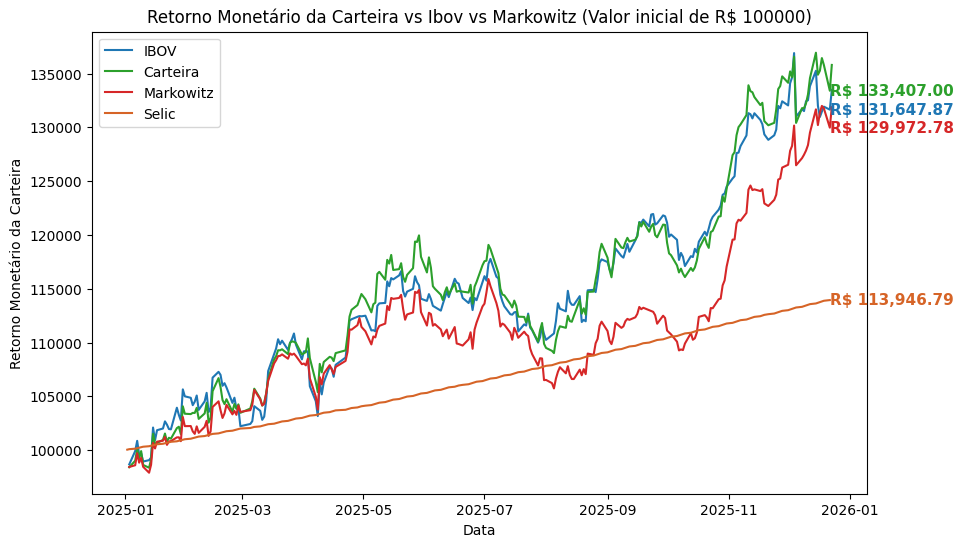

✅ Retornos acumulados salvos em: ../data/retornos_acumulados.csv



In [208]:
carteira_tempo = comp.print_results()

In [169]:

tics_selecionados = list(carteira_resultado['tickers_weights'].keys())

tics_selecionados_sa = [tic + ".SA" if not tic.endswith(".SA") else tic for tic in tics_selecionados]
print(tics_selecionados_sa)

df = yf.download(tics_selecionados_sa, start="2025-01-01")["Close"]

pesos = list(carteira_resultado['tickers_weights'].values()) 

comp = ComputandoMetricas("2025-01-01", "2025-12-31", tics_selecionados_sa, pesos, 100000)

#carteira_tempo = comp.print_results()

#carteira_tempo.to_csv("avaliacao_carteira.csv")

['ABEV3.SA', 'BBDC4.SA', 'BBAS3.SA', 'BRAP4.SA', 'CMIG3.SA', 'CSUD3.SA', 'EGIE3.SA', 'FIQE3.SA', 'WEGE3.SA']


C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\3444372168.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tics_selecionados_sa, start="2025-01-01")["Close"]
[*********************100%***********************]  9 of 9 completed
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1549867255.py:190: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ibov = yf.download("^BVSP", start=self.data_inicio, end=self.data_fim)["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1549867255.py:191: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.tics_selecionados, start=self.data_inicio, end=self.data_fim)["Close"]
[*********************100%***********************]  9 of 9 completed


In [ ]:
carteira_tempo = comp.print_results()